# UAS Kecerdasan Buatan

# Prediksi Risiko Stroke Menggunakan Algoritma Decision Tree dan K-Nearest Neighbor (KNN)

## Disusun Oleh

**Kelompok : 4**
- Haikal Muhamad Sabqi (2406020)
- Haikal Muhammad Rafi (2406032)

Program Studi Teknik Informatika
Universitas Institut Teknologi Garut

Tahun 2026

# 1. Business Understanding

## Latar Belakang

Stroke merupakan salah satu penyebab utama kematian dan kecacatan di berbagai negara. Deteksi dini terhadap risiko stroke sangat penting agar tindakan pencegahan dapat dilakukan lebih awal. Dengan memanfaatkan teknologi Machine Learning, data kesehatan pasien dapat dianalisis untuk memprediksi kemungkinan seseorang mengalami stroke berdasarkan beberapa faktor seperti usia, hipertensi, penyakit jantung, kadar glukosa, indeks massa tubuh (BMI), status merokok, dan karakteristik lainnya.

## Tujuan

- Melakukan analisis dataset Stroke Prediction.
- Melakukan preprocessing data.
- Membangun model Decision Tree.
- Membangun model KNN.
- Membandingkan performa kedua model.
- Menentukan model terbaik berdasarkan metrik evaluasi.

## Algoritma

- Decision Tree
- K-Nearest Neighbor (KNN)

In [2]:
# ============================================
# Import Library
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.tree import plot_tree

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


# 2. Load Dataset

Pada tahap ini dilakukan pembacaan dataset Stroke Prediction menggunakan library Pandas.

In [3]:
# Membaca dataset

df = pd.read_csv("data/healthcare-dataset-stroke-data.csv")

print("Dataset berhasil dimuat.")

Dataset berhasil dimuat.


In [4]:
# Menampilkan 5 data pertama

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
# Menampilkan ukuran dataset

print("Jumlah Baris :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

Jumlah Baris : 5110
Jumlah Kolom : 12


In [6]:
# Informasi dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [7]:
# Statistik deskriptif

df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [8]:
# Mengecek missing value

df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [9]:
# Mengecek data duplikat

print("Jumlah data duplikat :", df.duplicated().sum())

Jumlah data duplikat : 0


# 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik dataset, melihat distribusi data, mengetahui hubungan antar variabel, mendeteksi ketidakseimbangan kelas, serta memperoleh insight awal sebelum dilakukan proses preprocessing dan pemodelan.

stroke
0    4861
1     249
Name: count, dtype: int64


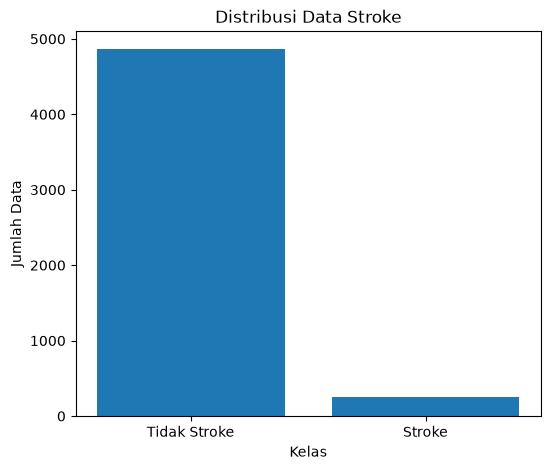

In [10]:
# Distribusi kelas target

stroke_counts = df["stroke"].value_counts()

print(stroke_counts)

plt.figure(figsize=(6,5))
plt.bar(["Tidak Stroke", "Stroke"], stroke_counts.values)

plt.title("Distribusi Data Stroke")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")

plt.show()

### Insight

Grafik menunjukkan distribusi jumlah pasien yang mengalami stroke dan yang tidak mengalami stroke. Apabila jumlah data pada salah satu kelas jauh lebih sedikit dibandingkan kelas lainnya, maka dataset termasuk **imbalanced dataset**. Kondisi ini perlu diperhatikan karena dapat mempengaruhi performa model klasifikasi.

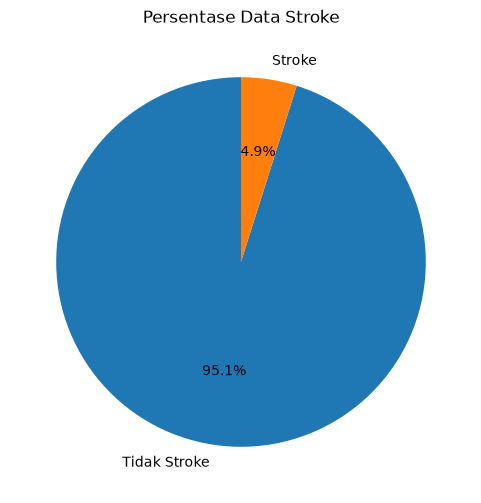

In [11]:
plt.figure(figsize=(6,6))

plt.pie(
    stroke_counts,
    labels=["Tidak Stroke","Stroke"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Persentase Data Stroke")

plt.show()

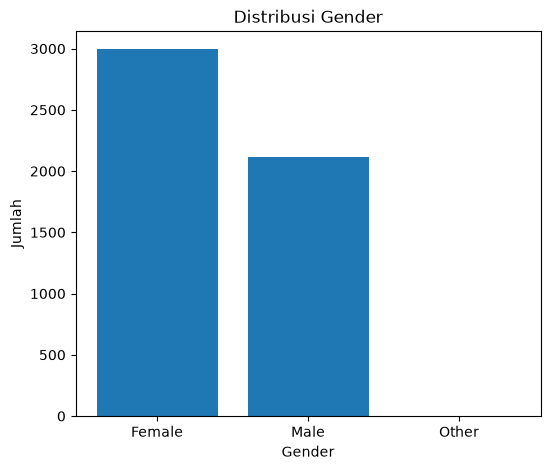

In [12]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(gender_counts.index, gender_counts.values)

plt.title("Distribusi Gender")
plt.xlabel("Gender")
plt.ylabel("Jumlah")

plt.show()

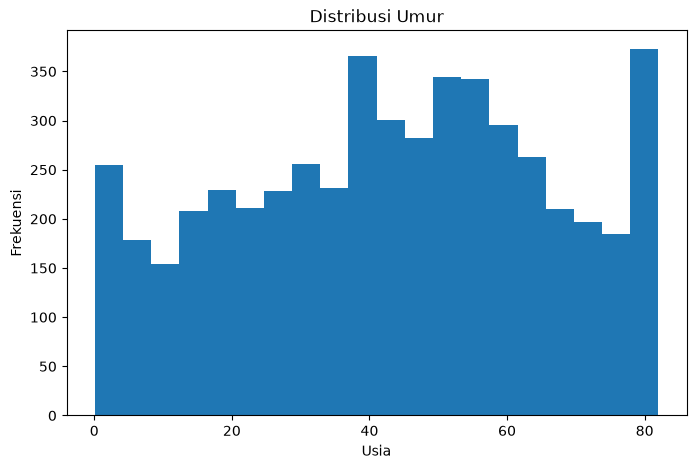

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=20)

plt.title("Distribusi Umur")
plt.xlabel("Usia")
plt.ylabel("Frekuensi")

plt.show()

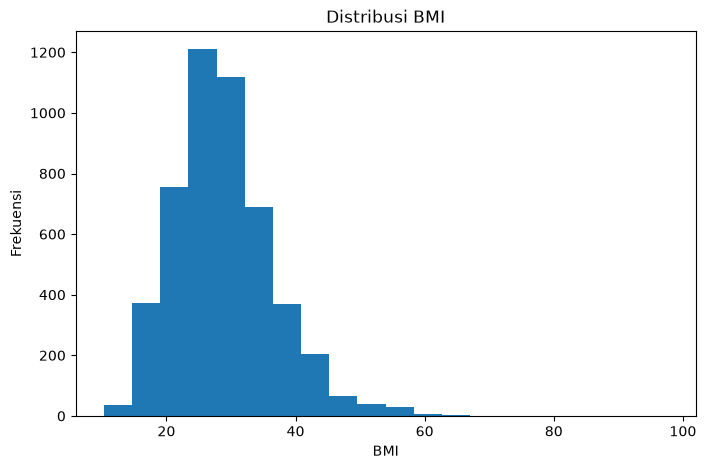

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["bmi"].dropna(), bins=20)

plt.title("Distribusi BMI")
plt.xlabel("BMI")
plt.ylabel("Frekuensi")

plt.show()

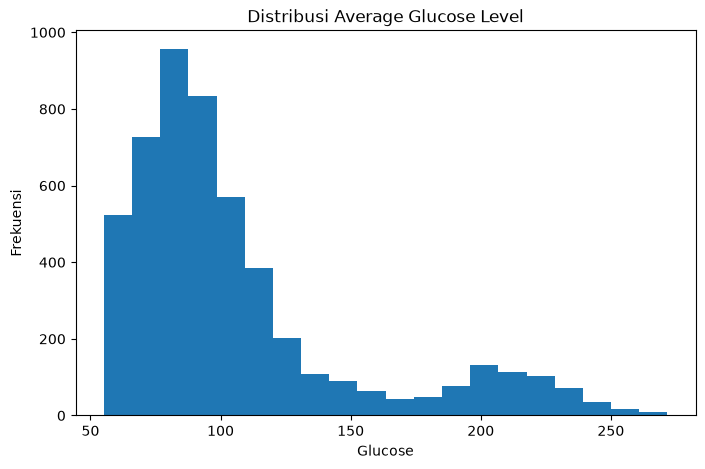

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df["avg_glucose_level"], bins=20)

plt.title("Distribusi Average Glucose Level")
plt.xlabel("Glucose")
plt.ylabel("Frekuensi")

plt.show()

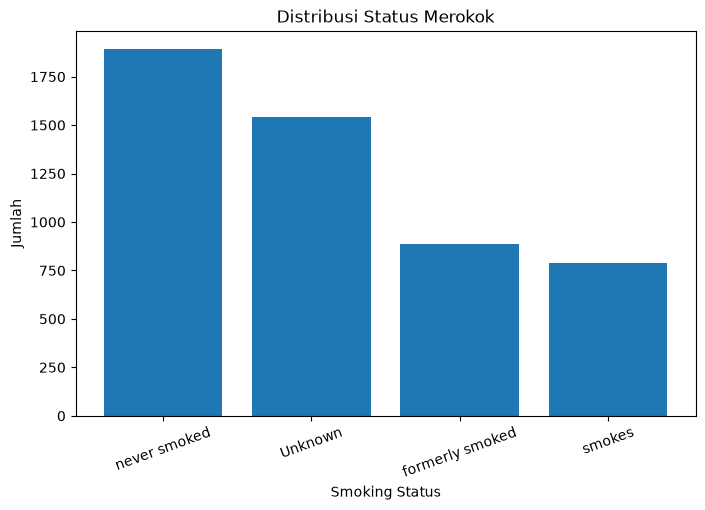

In [16]:
smoking = df["smoking_status"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(smoking.index, smoking.values)

plt.title("Distribusi Status Merokok")
plt.xlabel("Smoking Status")
plt.ylabel("Jumlah")

plt.xticks(rotation=20)

plt.show()

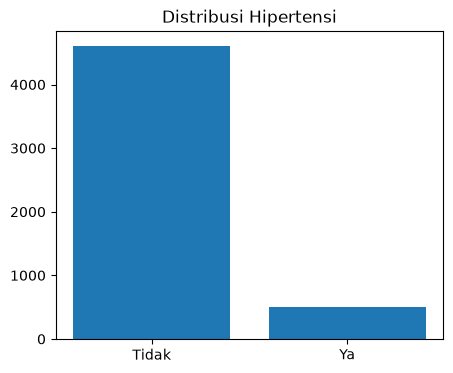

In [17]:
hyper = df["hypertension"].value_counts()

plt.figure(figsize=(5,4))

plt.bar(["Tidak","Ya"], hyper.values)

plt.title("Distribusi Hipertensi")

plt.show()

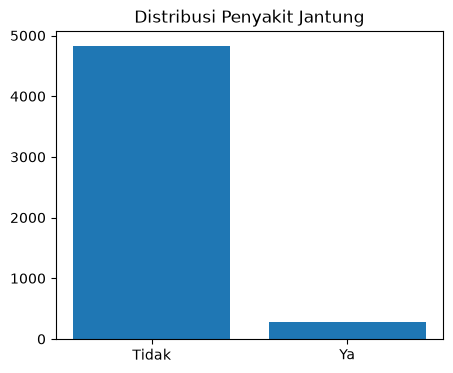

In [18]:
heart = df["heart_disease"].value_counts()

plt.figure(figsize=(5,4))

plt.bar(["Tidak","Ya"], heart.values)

plt.title("Distribusi Penyakit Jantung")

plt.show()

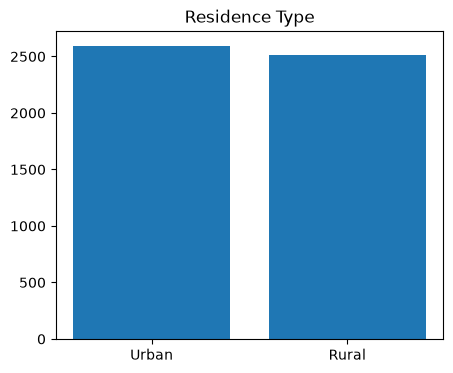

In [19]:
residence = df["Residence_type"].value_counts()

plt.figure(figsize=(5,4))

plt.bar(residence.index, residence.values)

plt.title("Residence Type")

plt.show()

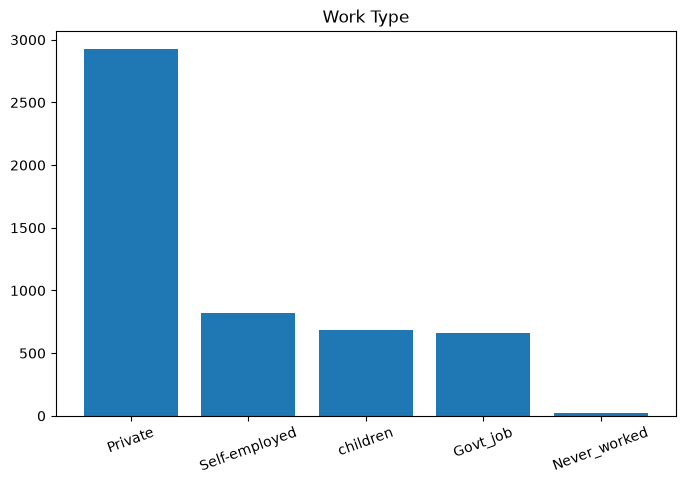

In [20]:
work = df["work_type"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(work.index, work.values)

plt.title("Work Type")

plt.xticks(rotation=20)

plt.show()

In [21]:
# Membuat salinan dataset untuk analisis korelasi
eda_df = df.copy()

encoder = LabelEncoder()

# Mengambil semua kolom bertipe object dan string
categorical_columns = eda_df.select_dtypes(include=["object", "string"]).columns

# Melakukan Label Encoding
for col in categorical_columns:
    eda_df[col] = encoder.fit_transform(eda_df[col].astype(str))

print("Encoding untuk heatmap berhasil.")

Encoding untuk heatmap berhasil.


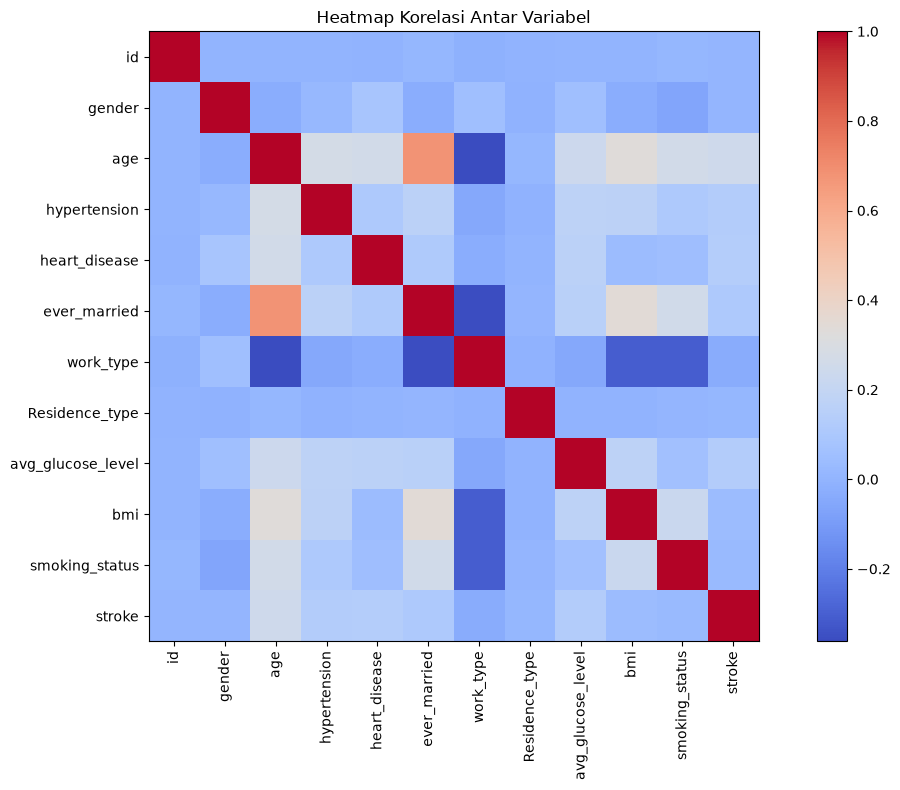

In [22]:
plt.figure(figsize=(12,8))

corr = eda_df.corr(numeric_only=True)

im = plt.imshow(corr, cmap="coolwarm", interpolation="nearest")

plt.colorbar(im)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Heatmap Korelasi Antar Variabel")

plt.tight_layout()

plt.show()

In [23]:
print("Korelasi terhadap variabel target (stroke):")
corr["stroke"].sort_values(ascending=False)

Korelasi terhadap variabel target (stroke):


stroke               1.000000
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
ever_married         0.108340
bmi                  0.042374
smoking_status       0.028123
Residence_type       0.015458
gender               0.008929
id                   0.006388
work_type           -0.032316
Name: stroke, dtype: float64

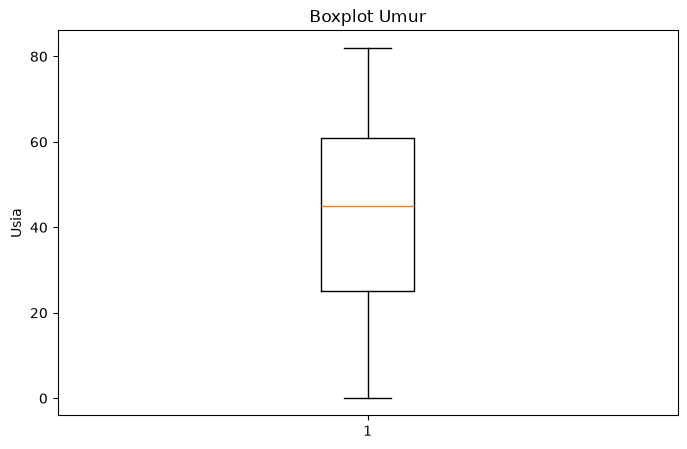

In [24]:
plt.figure(figsize=(8,5))

plt.boxplot(df["age"])

plt.title("Boxplot Umur")
plt.ylabel("Usia")

plt.show()

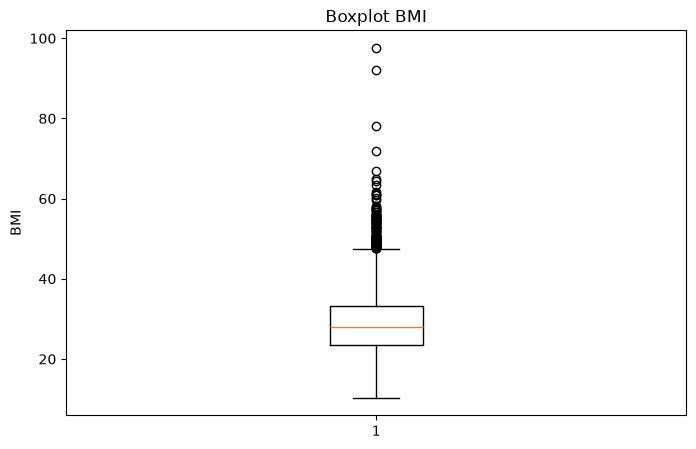

In [25]:
plt.figure(figsize=(8,5))

plt.boxplot(df["bmi"].dropna())

plt.title("Boxplot BMI")
plt.ylabel("BMI")

plt.show()

## Kesimpulan EDA

Berdasarkan hasil eksplorasi data diperoleh beberapa temuan awal sebagai berikut:

1. Dataset memiliki distribusi kelas yang tidak seimbang (imbalanced).
2. Terdapat nilai kosong (missing value) pada atribut BMI.
3. Variabel usia dan kadar glukosa menunjukkan variasi yang cukup tinggi.
4. Sebagian besar fitur kategorikal perlu dilakukan proses encoding sebelum digunakan dalam pemodelan.
5. Hasil analisis korelasi menunjukkan beberapa atribut memiliki hubungan terhadap variabel target sehingga layak digunakan sebagai fitur prediksi.

In [26]:
# Menampilkan matriks korelasi dalam bentuk tabel
corr.round(2)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
id,1.00,0.00,0.00,0.00,-0.00,0.01,-0.02,-0.00,0.00,0.00,0.01,0.01
gender,0.00,1.00,-0.03,0.02,0.09,-0.03,0.06,-0.01,0.06,-0.03,-0.06,0.01
age,0.00,-0.03,1.00,0.28,0.26,0.68,-0.36,0.01,0.24,0.33,0.27,0.25
hypertension,0.00,0.02,0.28,1.00,0.11,0.16,-0.05,-0.01,0.17,0.17,0.11,0.13
heart_disease,-0.00,0.09,0.26,0.11,1.00,0.11,-0.03,0.00,0.16,0.04,0.05,0.13
ever_married,0.01,-0.03,0.68,0.16,0.11,1.00,-0.35,0.01,0.16,0.34,0.26,0.11
work_type,-0.02,0.06,-0.36,-0.05,-0.03,-0.35,1.00,-0.01,-0.05,-0.30,-0.31,-0.03
Residence_type,-0.00,-0.01,0.01,-0.01,0.00,0.01,-0.01,1.00,-0.00,-0.00,0.01,0.02
avg_glucose_level,0.00,0.06,0.24,0.17,0.16,0.16,-0.05,-0.00,1.00,0.18,0.06,0.13
bmi,0.00,-0.03,0.33,0.17,0.04,0.34,-0.30,-0.00,0.18,1.00,0.22,0.04


# 4. Data Preparation

Pada tahap ini dilakukan proses persiapan data sebelum digunakan dalam pemodelan machine learning. Tahapan meliputi:

- Menghapus atribut yang tidak diperlukan
- Menangani missing value
- Melakukan encoding pada data kategorikal
- Memisahkan fitur dan target
- Membagi data menjadi data latih dan data uji
- Melakukan normalisasi data menggunakan StandardScaler

In [27]:
# Menghapus kolom id

df = df.drop(columns=["id"])

print("Kolom id berhasil dihapus.")
df.head()

Kolom id berhasil dihapus.


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [28]:
# Mengecek kembali missing value

print(df.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [29]:
# Mengisi missing value pada BMI menggunakan median

median_bmi = df["bmi"].median()

df["bmi"] = df["bmi"].fillna(median_bmi)

print("Missing value BMI berhasil diisi menggunakan median.")

Missing value BMI berhasil diisi menggunakan median.


In [30]:
# Memastikan tidak ada missing value

df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

## Label Encoding

Karena algoritma Decision Tree dan KNN hanya dapat memproses data numerik, maka seluruh atribut kategorikal diubah menjadi bentuk numerik menggunakan Label Encoding.

In [31]:
# Label Encoding

label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include=["object", "string"]).columns

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column].astype(str))

print("Semua data kategorikal berhasil diubah menjadi numerik.")

Semua data kategorikal berhasil diubah menjadi numerik.


In [32]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,0,61.0,0,0,1,3,0,202.21,28.1,2,1
2,1,80.0,0,1,1,2,0,105.92,32.5,2,1
3,0,49.0,0,0,1,2,1,171.23,34.4,3,1
4,0,79.0,1,0,1,3,0,174.12,24.0,2,1


In [33]:
# Memisahkan fitur dan target

X = df.drop("stroke", axis=1)

y = df["stroke"]

print("Jumlah fitur :", X.shape[1])
print("Jumlah data :", X.shape[0])

Jumlah fitur : 10
Jumlah data : 5110


In [34]:
# Membagi data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Latih :", X_train.shape)
print("Data Uji :", X_test.shape)

Data Latih : (4088, 10)
Data Uji : (1022, 10)


## Standardisasi Data

Standardisasi dilakukan karena algoritma K-Nearest Neighbor (KNN) menghitung jarak antar data. Agar setiap fitur memiliki skala yang seimbang, digunakan StandardScaler.

Decision Tree tidak memerlukan proses standardisasi, tetapi untuk menjaga konsistensi eksperimen, data hasil standardisasi akan digunakan pada model KNN.

In [35]:
# Standardisasi data

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Standardisasi selesai.")

Standardisasi selesai.


In [36]:
print("Shape Training :", X_train_scaled.shape)
print("Shape Testing :", X_test_scaled.shape)

Shape Training : (4088, 10)
Shape Testing : (1022, 10)


## Kesimpulan Data Preparation

Tahap Data Preparation telah berhasil dilakukan dengan langkah-langkah sebagai berikut:

1. Menghapus atribut `id` karena tidak memiliki pengaruh terhadap prediksi.
2. Mengatasi missing value pada atribut BMI menggunakan nilai median.
3. Mengubah seluruh atribut kategorikal menjadi numerik menggunakan Label Encoding.
4. Memisahkan fitur dan target.
5. Membagi dataset menjadi data latih (80%) dan data uji (20%).
6. Melakukan standardisasi data menggunakan StandardScaler untuk kebutuhan algoritma KNN.

# 5. Modeling

Pada tahap ini dilakukan pembangunan model machine learning menggunakan dua algoritma klasifikasi, yaitu Decision Tree dan K-Nearest Neighbor (KNN). Kedua model akan dilatih menggunakan data training yang telah dipersiapkan pada tahap Data Preparation, kemudian dievaluasi menggunakan data testing.

## 5.1 Decision Tree

Decision Tree merupakan algoritma klasifikasi yang bekerja dengan membangun struktur pohon keputusan berdasarkan atribut yang paling informatif. Algoritma ini dipilih karena mudah dipahami, cepat dalam proses pelatihan, serta mampu menangani data numerik maupun kategorikal.

In [37]:
# Membuat model Decision Tree

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    class_weight="balanced"
)

dt_model.fit(X_train, y_train)

print("Model Decision Tree berhasil dibuat.")

Model Decision Tree berhasil dibuat.


In [38]:
# Prediksi menggunakan Decision Tree

y_pred_dt = dt_model.predict(X_test)

print("Prediksi selesai.")

Prediksi selesai.


In [39]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Accuracy Decision Tree :", round(dt_accuracy,4))

Accuracy Decision Tree : 0.8268


In [40]:
dt_precision = precision_score(y_test, y_pred_dt)

print("Precision :", round(dt_precision,4))

Precision : 0.1777


In [41]:
dt_recall = recall_score(y_test, y_pred_dt)

print("Recall :", round(dt_recall,4))

Recall : 0.7


In [42]:
dt_f1 = f1_score(y_test, y_pred_dt)

print("F1 Score :", round(dt_f1,4))

F1 Score : 0.2834


In [43]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[810 162]
 [ 15  35]]


In [44]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.98      0.83      0.90       972
           1       0.18      0.70      0.28        50

    accuracy                           0.83      1022
   macro avg       0.58      0.77      0.59      1022
weighted avg       0.94      0.83      0.87      1022



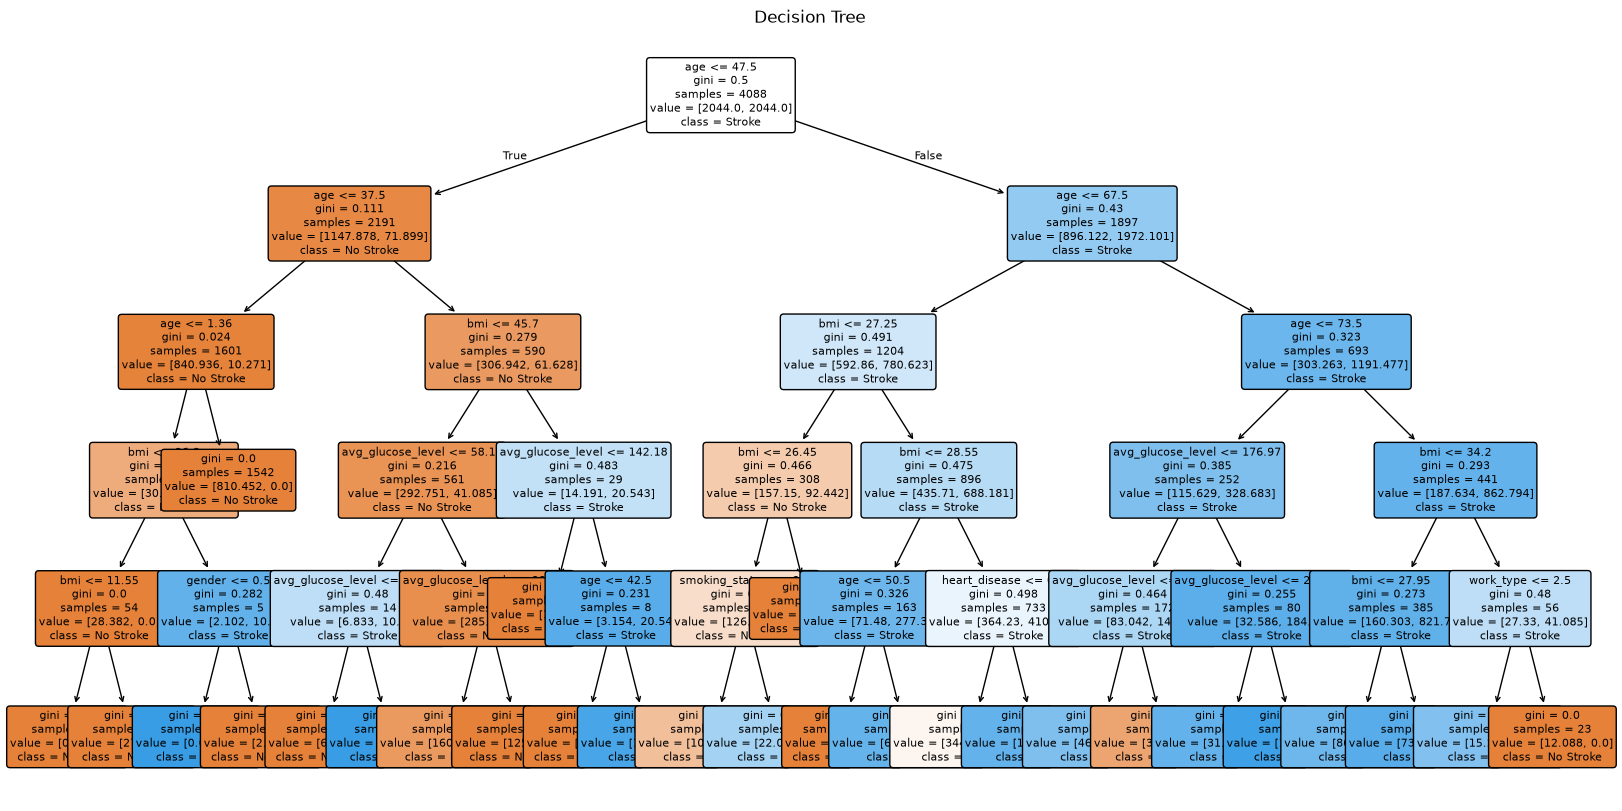

In [45]:
plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    filled=True,
    feature_names=X.columns,
    class_names=["No Stroke","Stroke"],
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree")

plt.show()

### Kesimpulan Sementara Decision Tree

Model Decision Tree berhasil dibangun dan digunakan untuk melakukan prediksi terhadap data testing. Selanjutnya performa model akan dibandingkan dengan algoritma K-Nearest Neighbor (KNN) menggunakan metrik Accuracy, Precision, Recall, dan F1-Score.

In [46]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)

print("Model KNN berhasil dibuat.")

Model KNN berhasil dibuat.


In [47]:
y_pred_knn = knn_model.predict(
    X_test_scaled
)

print("Prediksi selesai.")

Prediksi selesai.


In [48]:
knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

print("Accuracy :", round(knn_accuracy,4))

Accuracy : 0.9481


In [49]:
knn_precision = precision_score(
    y_test,
    y_pred_knn
)

print("Precision :", round(knn_precision,4))

Precision : 0.2


In [50]:
knn_recall = recall_score(
    y_test,
    y_pred_knn
)

print("Recall :", round(knn_recall,4))

Recall : 0.02


In [51]:
knn_f1 = f1_score(
    y_test,
    y_pred_knn
)

print("F1 Score :", round(knn_f1,4))

F1 Score : 0.0364


In [52]:
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

print(cm_knn)

[[968   4]
 [ 49   1]]


In [53]:
print(
    classification_report(
        y_test,
        y_pred_knn
    )
)

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.20      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.58      0.51      0.50      1022
weighted avg       0.92      0.95      0.93      1022



### Kesimpulan Sementara KNN

Model K-Nearest Neighbor berhasil dibangun menggunakan data yang telah distandardisasi. Selanjutnya hasil evaluasi kedua model akan dibandingkan untuk menentukan algoritma dengan performa terbaik berdasarkan metrik evaluasi yang digunakan.